In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar la ruta para importar 'Source'
# Agregamos la carpeta raíz al path de Python
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# 2. Activar Autoreload (Vital para desarrollo)
%load_ext autoreload
%autoreload 2

# 3. Importar tus clases de FEM
from Source.Pre_processing.Mesh import Mesh
from Source.core import Model
from Source.Material import material
from Source.Physics.HeatTransfer import ht

from Source.enums import ElementType, ShapeFunctionType, StudyType, ProblemType, SolverType

print("Entorno FEM-Sim cargado correctamente.")

Entorno FEM-Sim cargado correctamente.


In [2]:
PD = 1  # Problem Dimension: 1->1D; 2->2D(!); 3->3D(!)

# Create mesh from linear element

L = 2  # Length size of the domain [m]
NoE = 10  # Number of Elements
MeshType = ElementType.line  # Type of element
shapeFunction = ShapeFunctionType.linear  # Shape function for spatial discretization

In [3]:
Mesh1 = Mesh()
Mesh1.Generate_Mesh(PD, L, NoE, MeshType)
Mesh1.setElementShapeFunction(shapeFunction)

Mesh1.defineBoundary('inlet', 0)
Mesh1.defineBoundary('outlet', NoE) # Hardcoded

In [9]:
Mat1 = material('Aluminio', k = 15.0, miu=1, rho=7800, Cp= 480)

In [ ]:
Model1 = Model(name='1D_Conductivity', mtype=None, dim=PD, mesh=Mesh1, mat=Mat1, psc=ht)

Model1.physics.addBC_Temperature(id=Mesh1.boundaries['inlet'], T=60)
Model1.physics.addBC_Radiation(Mesh1.boundaries['outlet'], 0.7, 26)

Model1.physics.Convection = False
Model1.physics.Stab = None

Model1.physics.initField('T', 60.0)

In [11]:
options = {'Study': StudyType.steady_state, 'Type': ProblemType.nonlinear, 'Method': SolverType.direct, 'Solver':'PARDISO'}


Model1.solverConfiguration(**options)

In [12]:
Model1.solve()

-------Simulation started-------
----- Iteration number: 1 -----

Tolerance for iteration number 1: 5.924408545634289e-07

method finished on 1.538 seconds
Simulation finished


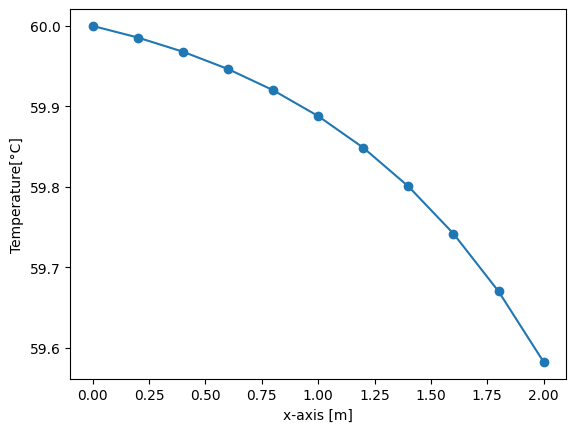

In [8]:
Model1.postProcess()
